In [205]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMRegressor, LGBMClassifier
import sys
import re
from sklearn.preprocessing import LabelEncoder
import plotly.express as px

In [206]:
df_listings = pd.read_csv("../data/Listing/listed_transactions.csv")
df_listings.head()

C:\Users\mayab\AppData\Local\Temp\ipykernel_5540\3410094314.py:1: DtypeWarning: Columns (0: ListAgentEmail, 1: BuyerAgencyCompensationType) have mixed types. Specify dtype option on import or set low_memory=False.
  df_listings = pd.read_csv("../data/Listing/listed_transactions.csv")


,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1,Year,year_month,rate_30yr_fixed
0,90000.0,1075010398,miriamlara03@gmail.com,NaN,NaN,Miriam,Lara,34.097939,-117.909653,1045 N Azusa 61,...,Covina Valley Unified,91722,NaN,0.0,NaN,NaN,1045 N Azusa 61,2024,2024-01,6.6425
1,1500000.0,1074974457,janelle@judsonre.com,NaN,NaN,Janelle,Judson,33.121241,-117.081614,NaN,...,NaN,92025,NaN,0.0,NaN,NaN,NaN,2024,2024-01,6.6425
2,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,NaN,90067,NaN,2105.0,177861.0,NaN,2220 Avenue Of The Stars 2704,2024,2024-01,6.6425
3,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,Capistrano Unified,92677,NaN,254.0,5300.0,NaN,16 Palisades,2024,2024-01,6.6425
4,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,NaN,91108,NaN,NaN,9404.0,NaN,1615 Waverly Road,2024,2024-01,6.6425


##### Number of Rows and Columns

In [207]:
df_listings.shape

(853754, 87)

The listing transactions file has 853754 rows and 87 columns. 

##### Review column data types

In [208]:
df_listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 853754 entries, 0 to 853753
Data columns (total 87 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   OriginalListPrice             850444 non-null  float64
 1   ListingKey                    853754 non-null  int64  
 2   ListAgentEmail                780379 non-null  str    
 3   CloseDate                     255893 non-null  str    
 4   ClosePrice                    233059 non-null  float64
 5   ListAgentFirstName            848740 non-null  str    
 6   ListAgentLastName             853678 non-null  str    
 7   Latitude                      741807 non-null  float64
 8   Longitude                     742511 non-null  float64
 9   UnparsedAddress               851597 non-null  str    
 10  PropertyType                  853754 non-null  str    
 11  LivingArea                    747280 non-null  float64
 12  ListPrice                     851619 non-null  float64


### UPDATE: Will no longer use LightGBM (unreliable unless we do further research)

In [209]:
df_listings.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'PropertyType.1', 'MlsStatus',
       'ElementarySchool', 'ListAgentFirstName.1', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'DaysOnMarket.1',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'LivingArea.1',
       'ListingId', 'BathroomsTotalInteger', 'Cit

In [210]:
df_listings.isna().sum()

OriginalListPrice                 3310
ListingKey                           0
ListAgentEmail                   73375
CloseDate                       597861
ClosePrice                      620695
                                 ...  
MiddleOrJuniorSchoolDistrict    853754
UnparsedAddress.1                 2157
Year                                 0
year_month                           0
rate_30yr_fixed                      0
Length: 87, dtype: int64

#### **Missing Value Analysis**

##### Calculate missing counts and percentages per column

In [211]:
missing_listing_counts = df_listings.isnull().sum()
missing_listing_counts

OriginalListPrice                 3310
ListingKey                           0
ListAgentEmail                   73375
CloseDate                       597861
ClosePrice                      620695
                                 ...  
MiddleOrJuniorSchoolDistrict    853754
UnparsedAddress.1                 2157
Year                                 0
year_month                           0
rate_30yr_fixed                      0
Length: 87, dtype: int64

In [212]:
missing_listing_percent = (df_listings.isnull().mean()) * 100
missing_listing_percent

OriginalListPrice                 0.387700
ListingKey                        0.000000
ListAgentEmail                    8.594396
CloseDate                        70.027315
ClosePrice                       72.701856
                                   ...    
MiddleOrJuniorSchoolDistrict    100.000000
UnparsedAddress.1                 0.252649
Year                              0.000000
year_month                        0.000000
rate_30yr_fixed                   0.000000
Length: 87, dtype: float64

In [213]:
missing_summary = pd.DataFrame({
    "missing_listing_counts": missing_listing_counts,
    "missing_listing_percent": missing_listing_percent
})

In [214]:
missing_listing_summary = missing_summary.sort_values(by="missing_listing_percent", ascending=False)
print(missing_listing_summary)

                              missing_listing_counts  missing_listing_percent
CoveredSpaces                                 853754                    100.0
AboveGradeFinishedArea                        853754                    100.0
MiddleOrJuniorSchoolDistrict                  853754                    100.0
ElementarySchoolDistrict                      853754                    100.0
FireplacesTotal                               853754                    100.0
...                                              ...                      ...
MlsStatus                                          0                      0.0
ListingContractDate                                0                      0.0
Year                                               0                      0.0
year_month                                         0                      0.0
rate_30yr_fixed                                    0                      0.0

[87 rows x 2 columns]


In [215]:
missing_listing_summary = missing_listing_summary[missing_listing_summary["missing_listing_counts"] > 0]
print(missing_listing_summary)

                              missing_listing_counts  missing_listing_percent
CoveredSpaces                                 853754               100.000000
AboveGradeFinishedArea                        853754               100.000000
MiddleOrJuniorSchoolDistrict                  853754               100.000000
ElementarySchoolDistrict                      853754               100.000000
FireplacesTotal                               853754               100.000000
...                                              ...                      ...
PostalCode                                       208                 0.024363
ListAgentLastName                                 76                 0.008902
ListAgentLastName.1                               76                 0.008902
StateOrProvince                                   66                 0.007731
CountyOrParish                                     1                 0.000117

[74 rows x 2 columns]


In [216]:
missing_listing_summary["missing_listing_percent"] = missing_listing_summary["missing_listing_percent"].round(2)
print(missing_listing_summary)

                              missing_listing_counts  missing_listing_percent
CoveredSpaces                                 853754                   100.00
AboveGradeFinishedArea                        853754                   100.00
MiddleOrJuniorSchoolDistrict                  853754                   100.00
ElementarySchoolDistrict                      853754                   100.00
FireplacesTotal                               853754                   100.00
...                                              ...                      ...
PostalCode                                       208                     0.02
ListAgentLastName                                 76                     0.01
ListAgentLastName.1                               76                     0.01
StateOrProvince                                   66                     0.01
CountyOrParish                                     1                     0.00

[74 rows x 2 columns]


In [217]:
missing_above_90 = missing_listing_summary[missing_listing_summary['missing_listing_percent'] > 90]
print(missing_above_90)

                              missing_listing_counts  missing_listing_percent
CoveredSpaces                                 853754                   100.00
AboveGradeFinishedArea                        853754                   100.00
MiddleOrJuniorSchoolDistrict                  853754                   100.00
ElementarySchoolDistrict                      853754                   100.00
FireplacesTotal                               853754                   100.00
TaxYear                                       852886                    99.90
BelowGradeFinishedArea                        850334                    99.60
BusinessType                                  847779                    99.30
TaxAnnualAmount                               847661                    99.29
CoBuyerAgentFirstName                         834049                    97.69
BuilderName                                   824452                    96.57
LotSizeDimensions                             805053            

In [218]:
missing_above_70 = missing_listing_summary[missing_listing_summary['missing_listing_percent'] > 70]
print(missing_above_70)

                              missing_listing_counts  missing_listing_percent
CoveredSpaces                                 853754                   100.00
AboveGradeFinishedArea                        853754                   100.00
MiddleOrJuniorSchoolDistrict                  853754                   100.00
ElementarySchoolDistrict                      853754                   100.00
FireplacesTotal                               853754                   100.00
TaxYear                                       852886                    99.90
BelowGradeFinishedArea                        850334                    99.60
BusinessType                                  847779                    99.30
TaxAnnualAmount                               847661                    99.29
CoBuyerAgentFirstName                         834049                    97.69
BuilderName                                   824452                    96.57
LotSizeDimensions                             805053            

In [219]:
missing_above_70.shape

(31, 2)

In [220]:
missing_above_70

,missing_listing_counts,missing_listing_percent
CoveredSpaces,853754,100.00
AboveGradeFinishedArea,853754,100.00
MiddleOrJuniorSchoolDistrict,853754,100.00
ElementarySchoolDistrict,853754,100.00
FireplacesTotal,853754,100.00
TaxYear,852886,99.90
BelowGradeFinishedArea,850334,99.60
BusinessType,847779,99.30
TaxAnnualAmount,847661,99.29
CoBuyerAgentFirstName,834049,97.69


To perserve the variables, it would be sufficient if each variable contain less than 70% of missing values in order to use imputation to replace the missingness in the data. 

So, variables with 70% of missing variables will be removed from the dataset because through imputation with variables with a significant number of missingness, it may contribute to bias towards certain values than others. 

Keep these key variables (from above 70):
- ClosePrice
- CloseDate

In [221]:
df_listings_clean = df_listings.drop(columns=['MiddleOrJuniorSchoolDistrict', 'ElementarySchoolDistrict', 'CoveredSpaces',
                                             'AboveGradeFinishedArea', 'FireplacesTotal', 'TaxYear', 
                                             'BelowGradeFinishedArea', 'BusinessType', 'TaxAnnualAmount',
                                             'CoBuyerAgentFirstName', 'BuilderName', 'LotSizeDimensions',
                                             'ElementarySchool', 'MiddleOrJuniorSchool', 'HighSchool',
                                             'BuyerAgencyCompensation', 'BuyerAgencyCompensationType', 'BuildingAreaTotal',
                                             'CoListAgentFirstName', 'CoListAgentLastName', 'CoListOfficeName', 'BuyerOfficeAOR',
                                             'BuyerOfficeName', 'BuyerOfficeName.1', 'AssociationFeeFrequency', 'BuyerAgentFirstName',
                                             'BuyerAgentMlsId', 'BuyerAgentLastName', 'CloseDate.1'])

Dropping Variables:
- MiddleOrJuniorSchoolDistrict                  
- ElementarySchoolDistrict
- CoveredSpaces
- AboveGradeFinishedArea
- FireplacesTotal
- TaxYear
- BelowGradeFinishedArea
- BusinessType
- TaxAnnualAmount
- CoBuyerAgentFirstName
- BuilderName
- LotSizeDimensions
- ElementarySchool
- MiddleOrJuniorSchool

In [222]:
# Calculate percentage for all columns
missing_pct = (df_listings_clean.isna().sum() / len(df_listings_clean)) * 100

# Filter to show only columns that actually have missing data
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

ClosePrice                  72.701856
CloseDate                   70.027315
SubdivisionName             66.606306
PurchaseContractDate        56.868372
MainLevelBedrooms           53.761622
HighSchoolDistrict          39.757237
AttachedGarageYN            34.093193
AssociationFee              32.320200
Stories                     25.941899
Levels                      19.215371
GarageSpaces                18.987085
FireplaceYN                 14.354369
NewConstructionYN           13.437243
Latitude                    13.112325
Latitude.1                  13.112325
Longitude.1                 13.029866
Longitude                   13.029866
LivingArea                  12.471274
LivingArea.1                12.471274
PropertySubType             12.201407
BedroomsTotal               12.073853
MLSAreaMajor                11.293066
LotSizeAcres                 9.554392
LotSizeSquareFeet            9.237556
LotSizeArea                  9.111875
ListAgentEmail               8.594396
BathroomsTot

In [223]:
num_cols_with_missing = df_listings_clean.isna().any().sum()

print(f"Number of variables with missing values: {num_cols_with_missing}")

Number of variables with missing values: 45


In [224]:
cols_rows_dropping = missing_pct[(missing_pct < 1) & (missing_pct > 0)]
cols_rows_dropping

OriginalListPrice           0.387700
ListAgentFirstName          0.587289
ListAgentLastName           0.008902
UnparsedAddress             0.252649
ListPrice                   0.250072
ListAgentFullName           0.026706
CountyOrParish              0.000117
ListAgentFirstName.1        0.587289
StreetNumberNumeric         0.441813
City                        0.112562
ContractStatusChangeDate    0.809484
ListPrice.1                 0.250072
StateOrProvince             0.007731
ListAgentLastName.1         0.008902
PostalCode                  0.024363
UnparsedAddress.1           0.252649
dtype: float64

In [225]:
cols_rows_dropped = ['OriginalListPrice', 'ListAgentFirstName', 'ListAgentLastName', 'UnparsedAddress', 'ListPrice', 'ListAgentFullName', 'CountyOrParish',
        'StreetNumberNumeric', 'City', 'ContractStatusChangeDate','StateOrProvince', 'PostalCode']

In [226]:
df_listings_clean = df_listings_clean.dropna(subset=['OriginalListPrice', 'ListAgentFirstName', 'ListAgentLastName', 'UnparsedAddress', 'ListPrice', 'ListAgentFullName', 'CountyOrParish',
        'StreetNumberNumeric', 'City', 'ContractStatusChangeDate','StateOrProvince', 'PostalCode'])

In [227]:
df_listings_clean.shape

(833710, 58)

In [228]:
# Create a reference mapping of Names -> Emails
# Drop any rows that have missing emails so the map is 'clean'
email_lookup = df_listings_clean.dropna(subset=['ListAgentEmail']).drop_duplicates(['ListAgentFirstName', 'ListAgentLastName'])

# Set the names as the index to make the 'lookup' possible
email_lookup = email_lookup.set_index(['ListAgentFirstName', 'ListAgentLastName'])['ListAgentEmail']

# Create a function to apply the logic
def fill_missing_emails(row):
    # Only try to fill if the current email is missing
    if pd.isna(row['ListAgentEmail']):
        # Look up the name in our reference map
        return email_lookup.get((row['ListAgentFirstName'], row['ListAgentLastName']), "None")
    return row['ListAgentEmail']

# Apply it to the dataframe
df_listings_clean['ListAgentEmail'] = df_listings_clean.apply(fill_missing_emails, axis=1)

In [229]:
df_listings_clean['ListAgentEmail'].isna().sum()

np.int64(0)

In [230]:
(df_listings_clean['ListAgentEmail'] == 'None').sum()

np.int64(3297)

From the code above, I noticed that there are no missing values for list agent's first and last names, so to determine their emails, I tried to look up any matches by full name to get the list agent's emails for the rows that are missing them. If there are no matches, those emails will be preserved by having a value of "None" (i.e. no email provided).

In [231]:
df_listings_clean.isna().sum()

OriginalListPrice                0
ListingKey                       0
ListAgentEmail                   0
CloseDate                   582499
ClosePrice                  603953
ListAgentFirstName               0
ListAgentLastName                0
Latitude                    108404
Longitude                   107727
UnparsedAddress                  0
PropertyType                     0
LivingArea                  100952
ListPrice                        0
DaysOnMarket                     0
ListOfficeName                   0
ListAgentFullName                0
ListingKeyNumeric                0
MLSAreaMajor                 93897
CountyOrParish                   0
PropertyType.1                   0
MlsStatus                        0
ListAgentFirstName.1             0
AttachedGarageYN            283027
ParkingTotal                 49684
PropertySubType             100629
LotSizeAcres                 79474
SubdivisionName             555061
YearBuilt                    66207
DaysOnMarket.1      

In [232]:
df_listings_clean.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'ListAgentFullName',
       'ListingKeyNumeric', 'MLSAreaMajor', 'CountyOrParish', 'PropertyType.1',
       'MlsStatus', 'ListAgentFirstName.1', 'AttachedGarageYN', 'ParkingTotal',
       'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'YearBuilt',
       'DaysOnMarket.1', 'StreetNumberNumeric', 'LivingArea.1', 'ListingId',
       'BathroomsTotalInteger', 'City', 'BedroomsTotal',
       'ContractStatusChangeDate', 'Longitude.1', 'PurchaseContractDate',
       'ListingContractDate', 'Latitude.1', 'ListPrice.1', 'StateOrProvince',
       'FireplaceYN', 'Stories', 'Levels', 'ListAgentLastName.1',
       'LotSizeArea', 'MainLevelBedrooms', 'NewConstructionYN', 'GarageSpaces',
       'HighSchoolDistrict', 'PostalCode'

#### **Convert date fields to datetime format (CloseDate, PurchaseContractDate, ListingContractDate, ContractStatusChangeDate)**

In [233]:
df_listings_clean['CloseDate'] = pd.to_datetime(df_listings_clean['CloseDate'], errors='coerce')

In [234]:
df_listings_clean['PurchaseContractDate'] = pd.to_datetime(df_listings_clean['PurchaseContractDate'], errors='coerce')

In [235]:
df_listings_clean['ListingContractDate'] = pd.to_datetime(df_listings_clean['ListingContractDate'], errors='coerce')

In [236]:
df_listings_clean['ContractStatusChangeDate'] = pd.to_datetime(df_listings_clean['ContractStatusChangeDate'], errors='coerce')

In [237]:
print(df_listings_clean['PurchaseContractDate'].dtype)

datetime64[us]


#### **Remove unnecessary or redundant columns**

In [238]:
df_listings_clean.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'ListAgentFullName',
       'ListingKeyNumeric', 'MLSAreaMajor', 'CountyOrParish', 'PropertyType.1',
       'MlsStatus', 'ListAgentFirstName.1', 'AttachedGarageYN', 'ParkingTotal',
       'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'YearBuilt',
       'DaysOnMarket.1', 'StreetNumberNumeric', 'LivingArea.1', 'ListingId',
       'BathroomsTotalInteger', 'City', 'BedroomsTotal',
       'ContractStatusChangeDate', 'Longitude.1', 'PurchaseContractDate',
       'ListingContractDate', 'Latitude.1', 'ListPrice.1', 'StateOrProvince',
       'FireplaceYN', 'Stories', 'Levels', 'ListAgentLastName.1',
       'LotSizeArea', 'MainLevelBedrooms', 'NewConstructionYN', 'GarageSpaces',
       'HighSchoolDistrict', 'PostalCode'

In [239]:
df_listings_clean.shape

(833710, 58)

In [240]:
df_listings_clean = df_listings_clean.drop(columns=['PropertyType.1', 'ListAgentFirstName.1', 'DaysOnMarket.1', 'LivingArea.1', 'Longitude.1', 
                                                        'Latitude.1', 'ListPrice.1', 'ListAgentLastName.1', 'UnparsedAddress.1'])

In [241]:
df_listings_clean.shape

(833710, 49)

In [242]:
(df_listings_clean['OriginalListPrice'] == df_listings_clean['ListPrice']).value_counts()

True     670462
False    163248
Name: count, dtype: int64

#### **Outlier Cleaning**

Remove or flag invalid numeric values: ClosePrice <=0, LivingArea <=0, DaysOnMarket < 0, negative Bedrooms or Bathrooms

Removing and inspecting negative values

In [243]:
neg_counts = (df_listings_clean.select_dtypes(include='number') < 0).sum()

In [244]:
neg_counts[neg_counts > 0]

Latitude             7
Longitude       725767
DaysOnMarket        37
ParkingTotal       165
dtype: int64

In [245]:
(neg_counts[neg_counts > 0] / df_listings_clean.shape[0] * 100).sort_values(ascending=False)

Longitude       87.052692
ParkingTotal     0.019791
DaysOnMarket     0.004438
Latitude         0.000840
dtype: float64

ParkingTotal        

In [246]:
neg_ParkingTotal = df_listings_clean[df_listings_clean['ParkingTotal'] < 0]
neg_ParkingTotal.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,Year,year_month,rate_30yr_fixed
8443,2300000.0,1058688466,mabroukhamza093@gmail.com,NaT,NaN,Hamza,Mabrouk,NaN,NaN,725 Hyde Street,...,NaN,NaN,NaN,San Francisco Unified,94109,0.0,1650.0,2024,2024-01,6.6425
12223,1258000.0,1058416008,trisha@trishamotter.com,2024-02-15,1600000.0,Trisha,Motter,NaN,NaN,7385 Forsum Road,...,NaN,False,2.0,Other,95138,NaN,5227.0,2024,2024-01,6.6425
26306,1588888.0,1054056032,maryoproperties@yahoo.com,2024-02-23,1550000.0,Mary,O'neill,NaN,NaN,2965 Calle De Las Estrella,...,NaN,False,2.0,Other,95148,120.0,3920.0,2024,2024-01,6.6425
30751,1599000.0,1061806243,kroyer.re@gmail.com,2024-04-02,1620000.0,Kathy,Royer,NaN,NaN,6088 Pietz Court,...,NaN,False,2.0,San Jose Unified,95123,NaN,6098.0,2024,2024-02,6.7760
31804,1400000.0,1061770369,rick.talmage@compass.com,2024-03-27,1550000.0,Rick,Talmage,NaN,NaN,994 La Mesa Terrace E,...,NaN,False,2.0,Other,94086,655.0,NaN,2024,2024-02,6.7760


In [247]:
neg_ParkingTotal.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,Year,year_month,rate_30yr_fixed
8443,2300000.0,1058688466,mabroukhamza093@gmail.com,NaT,NaN,Hamza,Mabrouk,NaN,NaN,725 Hyde Street,...,NaN,NaN,NaN,San Francisco Unified,94109,0.0,1650.0,2024,2024-01,6.6425
12223,1258000.0,1058416008,trisha@trishamotter.com,2024-02-15,1600000.0,Trisha,Motter,NaN,NaN,7385 Forsum Road,...,NaN,False,2.0,Other,95138,NaN,5227.0,2024,2024-01,6.6425
26306,1588888.0,1054056032,maryoproperties@yahoo.com,2024-02-23,1550000.0,Mary,O'neill,NaN,NaN,2965 Calle De Las Estrella,...,NaN,False,2.0,Other,95148,120.0,3920.0,2024,2024-01,6.6425
30751,1599000.0,1061806243,kroyer.re@gmail.com,2024-04-02,1620000.0,Kathy,Royer,NaN,NaN,6088 Pietz Court,...,NaN,False,2.0,San Jose Unified,95123,NaN,6098.0,2024,2024-02,6.7760
31804,1400000.0,1061770369,rick.talmage@compass.com,2024-03-27,1550000.0,Rick,Talmage,NaN,NaN,994 La Mesa Terrace E,...,NaN,False,2.0,Other,94086,655.0,NaN,2024,2024-02,6.7760


In [248]:
df_listings_clean['ParkingTotal'].describe()

count    7.840260e+05
mean     6.505778e+00
std      2.938914e+03
min     -1.430000e+02
25%      1.000000e+00
50%      2.000000e+00
75%      3.000000e+00
max      2.593669e+06
Name: ParkingTotal, dtype: float64

DaysOnMarket              

In [249]:
neg_DaysOnMarket = df_listings_clean[df_listings_clean['DaysOnMarket'] < 0]
neg_DaysOnMarket.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,Year,year_month,rate_30yr_fixed
223,799000.0,1063549350,ainsleyhughes@kw.com,2024-03-21,799000.0,Ainsley,Hughes,34.425577,-119.291855,11905 Silver Spur Street,...,NaN,NaN,2.0,NaN,93023,59.0,5885.0,2024,2024-01,6.6425
228,899000.0,1063528331,absea@comcast.net,2024-03-19,810000.0,A.B.,Priceman DRE 0126...,39.383806,-123.789254,31530 Emerald Drive,...,NaN,False,2.0,NaN,95437,NaN,34848.0,2024,2024-01,6.6425
752,11500.0,1061271257,teresa.fuller@compass.com,2024-03-07,10500.0,Teresa,Fuller,34.081125,-118.363403,536 N Edinburgh Avenue,...,5.0,NaN,0.0,NaN,90048,0.0,6612.0,2024,2024-01,6.6425
1119,1599000.0,1060153479,robert@anppros.com,2024-03-21,1625000.0,Robert,Perez,34.244449,-118.265167,3929 El Moreno Street,...,NaN,NaN,2.0,NaN,91214,NaN,5249.0,2024,2024-01,6.6425
4167,469999.0,1059512539,khoren9@yahoo.com,NaT,NaN,Khoren,Barutyan,34.201700,-118.460053,15015 Sherman Way 103,...,0.0,False,2.0,Los Angeles Unified,91405,390.0,15574.0,2024,2024-01,6.6425


In [250]:
rows_DaysOnMarket = neg_DaysOnMarket['DaysOnMarket']
rows_DaysOnMarket.head()

223    -48
228    -58
752    -16
1119    -1
4167   -33
Name: DaysOnMarket, dtype: int64

In [251]:
non_neg = (df_listings_clean['DaysOnMarket'] >= 0) & (df_listings_clean['ParkingTotal'] >= 0)

In [252]:
df_listings_clean = df_listings_clean[non_neg].copy()

In [253]:
df_listings_clean.shape

(783825, 49)

In [254]:
neg_counts = (df_listings_clean.select_dtypes(include='number') < 0).sum()

In [255]:
neg_counts[neg_counts > 0]

Latitude          4
Longitude    680607
dtype: int64

In [256]:
df_listings_clean = df_listings_clean[
    (df_listings_clean['Latitude'] >= 32.5) & (df_listings_clean['Latitude'] <= 42.0) &
    (df_listings_clean['Longitude'] >= -124.5) & (df_listings_clean['Longitude'] <= -114.0)
]

In [257]:
df_listings_clean.shape

(679755, 49)

In [258]:
'''
df_map = df_listings_clean.sample(30000)

fig = px.scatter_mapbox(
    df_map,
    lat="Latitude",
    lon="Longitude",
    color="OriginalListPrice",
    size_max=15,
    zoom=5,
    title="California Property Value Distribution",
    color_continuous_scale=px.colors.sequential.Plasma,
    mapbox_style="open-street-map"
)

fig.show(renderer='browser')
'''

'\ndf_map = df_listings_clean.sample(30000)\n\nfig = px.scatter_mapbox(\n    df_map,\n    lat="Latitude",\n    lon="Longitude",\n    color="OriginalListPrice",\n    size_max=15,\n    zoom=5,\n    title="California Property Value Distribution",\n    color_continuous_scale=px.colors.sequential.Plasma,\n    mapbox_style="open-street-map"\n)\n\nfig.show(renderer=\'browser\')\n'

#### **Further Handling Missing Values Appropriately**

In [259]:
missing_listing_counts = df_listings_clean.isnull().sum()
missing_listing_counts

OriginalListPrice                0
ListingKey                       0
ListAgentEmail                   0
CloseDate                   461731
ClosePrice                  475198
ListAgentFirstName               0
ListAgentLastName                0
Latitude                         0
Longitude                        0
UnparsedAddress                  0
PropertyType                     0
LivingArea                   43230
ListPrice                        0
DaysOnMarket                     0
ListOfficeName                   0
ListAgentFullName                0
ListingKeyNumeric                0
MLSAreaMajor                 65007
CountyOrParish                   0
MlsStatus                        0
AttachedGarageYN            209037
ParkingTotal                     0
PropertySubType              50789
LotSizeAcres                 60366
SubdivisionName             452735
YearBuilt                    19689
StreetNumberNumeric              0
ListingId                        0
BathroomsTotalIntege

In [260]:
missing_listing_percent = (df_listings_clean.isnull().mean()) * 100
missing_listing_percent

OriginalListPrice            0.000000
ListingKey                   0.000000
ListAgentEmail               0.000000
CloseDate                   67.926091
ClosePrice                  69.907246
ListAgentFirstName           0.000000
ListAgentLastName            0.000000
Latitude                     0.000000
Longitude                    0.000000
UnparsedAddress              0.000000
PropertyType                 0.000000
LivingArea                   6.359644
ListPrice                    0.000000
DaysOnMarket                 0.000000
ListOfficeName               0.000000
ListAgentFullName            0.000000
ListingKeyNumeric            0.000000
MLSAreaMajor                 9.563299
CountyOrParish               0.000000
MlsStatus                    0.000000
AttachedGarageYN            30.751815
ParkingTotal                 0.000000
PropertySubType              7.471663
LotSizeAcres                 8.880553
SubdivisionName             66.602673
YearBuilt                    2.896485
StreetNumber

In [261]:
missing_summary = pd.DataFrame({
    "missing_listing_counts": missing_listing_counts,
    "missing_listing_percent": missing_listing_percent
})

In [262]:
missing_listing_summary = missing_summary.sort_values(by="missing_listing_percent", ascending=False)
print(missing_listing_summary)

                          missing_listing_counts  missing_listing_percent
ClosePrice                                475198                69.907246
CloseDate                                 461731                67.926091
SubdivisionName                           452735                66.602673
PurchaseContractDate                      370125                54.449765
MainLevelBedrooms                         325430                47.874602
HighSchoolDistrict                        240786                35.422468
AssociationFee                            217051                31.930769
AttachedGarageYN                          209037                30.751815
Stories                                   127204                18.713213
GarageSpaces                              100109                14.727218
NewConstructionYN                          84053                12.365190
Levels                                     76496                11.253466
MLSAreaMajor                          

In [163]:
missing_listing_summary[missing_listing_summary['missing_listing_percent'] > 0]

,missing_listing_counts,missing_listing_percent
ClosePrice,475198,69.907246
CloseDate,461731,67.926091
SubdivisionName,452735,66.602673
PurchaseContractDate,370125,54.449765
MainLevelBedrooms,325430,47.874602
HighSchoolDistrict,240786,35.422468
AssociationFee,217051,31.930769
AttachedGarageYN,209037,30.751815
Stories,127204,18.713213
GarageSpaces,100109,14.727218


In [60]:
continuous_columns = df_listings_clean.select_dtypes(include=['int64', 'float64']).columns

In [61]:
df_listings_clean[continuous_columns].corr(method = "spearman").round(2)

,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,ListingKeyNumeric,ParkingTotal,...,BathroomsTotalInteger,BedroomsTotal,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,Year,rate_30yr_fixed
OriginalListPrice,1.00,0.02,0.99,0.02,-0.12,0.49,1.00,0.03,0.02,0.32,...,0.37,0.44,0.16,0.07,0.08,0.35,0.21,0.08,0.04,-0.01
ListingKey,0.02,1.00,0.05,0.03,-0.03,-0.01,0.02,0.10,1.00,-0.00,...,-0.00,-0.00,0.00,0.00,-0.00,-0.01,0.03,0.00,0.91,-0.60
ClosePrice,0.99,0.05,1.00,0.03,-0.10,0.46,1.00,-0.09,0.05,0.34,...,0.33,0.44,0.10,0.04,0.13,0.34,0.28,0.05,0.05,-0.02
Latitude,0.02,0.03,0.03,1.00,-0.75,-0.00,0.02,0.04,0.03,-0.12,...,-0.07,0.04,-0.05,0.07,0.18,-0.03,-0.13,0.04,0.03,-0.02
Longitude,-0.12,-0.03,-0.10,-0.75,1.00,0.01,-0.12,-0.04,-0.03,0.11,...,0.02,-0.01,-0.01,-0.02,-0.06,0.05,0.02,0.01,-0.04,0.02
LivingArea,0.49,-0.01,0.46,-0.00,0.01,1.00,0.49,0.02,-0.01,0.50,...,0.80,0.79,0.41,0.14,0.01,0.61,-0.06,0.15,-0.00,0.02
ListPrice,1.00,0.02,1.00,0.02,-0.12,0.49,1.00,0.02,0.02,0.32,...,0.37,0.44,0.16,0.07,0.08,0.35,0.21,0.08,0.04,-0.01
DaysOnMarket,0.03,0.10,-0.09,0.04,-0.04,0.02,0.02,1.00,0.10,0.00,...,0.04,0.00,0.02,-0.00,-0.02,0.01,0.07,-0.01,0.03,-0.10
ListingKeyNumeric,0.02,1.00,0.05,0.03,-0.03,-0.01,0.02,0.10,1.00,-0.00,...,-0.00,-0.00,0.00,0.00,-0.00,-0.01,0.03,0.00,0.91,-0.60
ParkingTotal,0.32,-0.00,0.34,-0.12,0.11,0.50,0.32,0.00,-0.00,1.00,...,0.44,0.46,0.20,0.09,0.04,0.68,-0.03,0.10,-0.00,0.00


Text(0.5, 1.0, 'Correlation matrix')

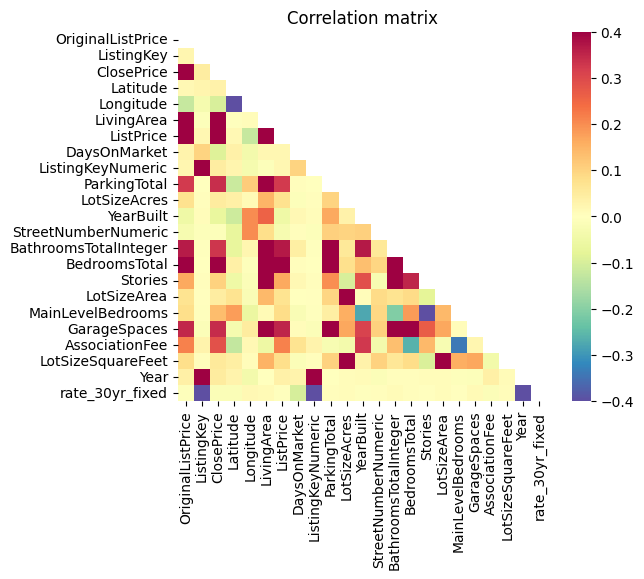

In [62]:
corrs =df_listings_clean[continuous_columns].corr(method = "spearman")
mask = np.zeros_like(corrs)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corrs, cmap='Spectral_r', mask=mask, square=True, vmin=-.4, vmax=.4)
plt.title('Correlation matrix')

In [63]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [70]:
corr_matrix = df_listings_clean[continuous_columns].corr(method="spearman").round(2)

moderate_corr = corr_matrix.stack()
moderate_corr = moderate_corr[(moderate_corr.abs() >= 0.3) & (moderate_corr.abs() < 0.7)]

print(moderate_corr)

OriginalListPrice      LivingArea               0.49
                       ParkingTotal             0.32
                       BathroomsTotalInteger    0.37
                       BedroomsTotal            0.44
                       GarageSpaces             0.35
ListingKey             rate_30yr_fixed         -0.60
ClosePrice             LivingArea               0.46
                       ParkingTotal             0.34
                       BathroomsTotalInteger    0.33
                       BedroomsTotal            0.44
                       GarageSpaces             0.34
LivingArea             OriginalListPrice        0.49
                       ClosePrice               0.46
                       ListPrice                0.49
                       ParkingTotal             0.50
                       Stories                  0.41
                       GarageSpaces             0.61
ListPrice              LivingArea               0.49
                       ParkingTotal           

- Under 10% missing -> simple statistical imputation method, but for categorical variables, may include a "Missing" category if deemed necessary
- 10-50% missing -> "Decision Zone" - meaning that there are different approaches that can be taken to impute the missing values like a group-based imputation, model-based if justifiable, adding a missing indicator, or doing simple imputation if necessary
- above 50% -> Since at this point, they are probably important features, the missingness in the data could be important and signals themselves. 

Let's start with "Under 10% missing"

In [184]:
under_10 = missing_listing_summary[(missing_listing_summary['missing_listing_percent'] < 10) & (missing_listing_percent != 0)]

C:\Users\mayab\AppData\Local\Temp\ipykernel_14772\2293341584.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  under_10 = missing_listing_summary[(missing_listing_summary['missing_listing_percent'] < 10) & (missing_listing_percent != 0)]


In [185]:
under_10

,missing_listing_counts,missing_listing_percent
MLSAreaMajor,65007,9.563299
LotSizeAcres,60366,8.880553
LotSizeSquareFeet,57784,8.500710
LotSizeArea,56830,8.360365
FireplaceYN,56766,8.350950
PropertySubType,50789,7.471663
LivingArea,43230,6.359644
BedroomsTotal,39667,5.835485
YearBuilt,19689,2.896485
BathroomsTotalInteger,15530,2.284647


In [263]:
df_listings_clean['MLSAreaMajor'].describe()

count                614748
unique                 1136
top       699 - Not Defined
freq                  51550
Name: MLSAreaMajor, dtype: object

In [264]:
df_listings_clean['MLSAreaMajor'].value_counts().head()

MLSAreaMajor
699 - Not Defined                     51550
SRCAR - Southwest Riverside County    26686
252 - Riverside                        7239
C14 - Santa Monica                     5484
C42 - Downtown L.A.                    5181
Name: count, dtype: int64

In [265]:
df_listings_clean['MLSAreaMajor'].value_counts(normalize=True).head()

MLSAreaMajor
699 - Not Defined                     0.083855
SRCAR - Southwest Riverside County    0.043410
252 - Riverside                       0.011776
C14 - Santa Monica                    0.008921
C42 - Downtown L.A.                   0.008428
Name: proportion, dtype: float64

In [266]:
df_listings_clean['MLSAreaMajor'] = df_listings_clean['MLSAreaMajor'].fillna("Missing")

In [267]:
df_listings_clean['MLSAreaMajor'].isna().sum()

np.int64(0)

In [268]:
df_listings_clean['LotSizeAcres'].describe()

count    6.193890e+05
mean     6.722773e+02
std      4.706031e+05
min      0.000000e+00
25%      1.200000e-01
50%      1.700000e-01
75%      3.287000e-01
max      3.702600e+08
Name: LotSizeAcres, dtype: float64

The mean is greater than the median. The values are skewed to the right. I will be using the median to impute. 

In [269]:
df_listings_clean['LotSizeArea'] = df_listings_clean['LotSizeArea'].fillna(df_listings_clean['LotSizeArea'].median())

In [270]:
df_listings_clean['LotSizeArea'].isna().sum()

np.int64(0)

In [271]:
df_listings_clean['LotSizeArea'].describe()

count    6.797550e+05
mean     5.085676e+04
std      2.380703e+06
min      0.000000e+00
25%      5.150000e+03
50%      7.200000e+03
75%      1.129100e+04
max      9.187423e+08
Name: LotSizeArea, dtype: float64

In [272]:
df_listings_clean['LotSizeSquareFeet'].describe()

count    6.219710e+05
mean     5.397025e+05
std      2.117726e+07
min      0.000000e+00
25%      5.227000e+03
50%      7.405000e+03
75%      1.417650e+04
max      3.472385e+09
Name: LotSizeSquareFeet, dtype: float64

The mean is less than the median. The values are skewed to the left. I will be using the median to impute the missing values. 

In [273]:
df_listings_clean['LotSizeSquareFeet'] = df_listings_clean['LotSizeSquareFeet'].fillna(df_listings_clean['LotSizeSquareFeet'].median())

In [274]:
df_listings_clean['LotSizeSquareFeet'].isna().sum()

np.int64(0)

In [275]:
df_listings_clean['LotSizeSquareFeet'].describe()

count    6.797550e+05
mean     4.944534e+05
std      2.025771e+07
min      0.000000e+00
25%      5.454000e+03
50%      7.405000e+03
75%      1.252900e+04
max      3.472385e+09
Name: LotSizeSquareFeet, dtype: float64

In [276]:
df_listings_clean['FireplaceYN'].value_counts()

FireplaceYN
True     372295
False    250694
Name: count, dtype: int64

In [277]:
df_listings_clean['FireplaceYN'].value_counts(normalize=True)

FireplaceYN
True     0.597595
False    0.402405
Name: proportion, dtype: float64

In [278]:
df_listings_clean['FireplaceYN'] = df_listings_clean['FireplaceYN'].fillna("Missing")

In [279]:
df_listings_clean['FireplaceYN'].value_counts()

FireplaceYN
True       372295
False      250694
Missing     56766
Name: count, dtype: int64

In [280]:
df_listings_clean['FireplaceYN'].isna().sum()

np.int64(0)

In [281]:
df_listings_clean['PropertySubType'].value_counts().head()

PropertySubType
SingleFamilyResidence    404416
Condominium              128617
Townhouse                 36597
Apartment                 17416
Duplex                    14438
Name: count, dtype: int64

In [282]:
df_listings_clean['PropertySubType'].value_counts(normalize=True).head()

PropertySubType
SingleFamilyResidence    0.642985
Condominium              0.204490
Townhouse                0.058186
Apartment                0.027690
Duplex                   0.022955
Name: proportion, dtype: float64

In [283]:
df_listings_clean['PropertySubType'] = df_listings_clean['PropertySubType'].fillna(df_listings_clean['PropertySubType'].mode()[0])

In [284]:
df_listings_clean['PropertySubType'].value_counts(normalize=True).head()

PropertySubType
SingleFamilyResidence    0.669660
Condominium              0.189211
Townhouse                0.053839
Apartment                0.025621
Duplex                   0.021240
Name: proportion, dtype: float64

In [285]:
df_listings_clean['LivingArea'].describe()

count    6.365250e+05
mean     3.377681e+03
std      1.139662e+06
min      0.000000e+00
25%      1.178000e+03
50%      1.600000e+03
75%      2.236000e+03
max      9.090909e+08
Name: LivingArea, dtype: float64

The mean is greater than the median, which shows that it is skewing to the right. I will then impute by the median rather than the mean.

In [286]:
df_listings_clean['LivingArea'] = df_listings_clean['LivingArea'].fillna(df_listings_clean['LivingArea'].median())

In [287]:
df_listings_clean['LivingArea'].describe()

count    6.797550e+05
mean     3.264627e+03
std      1.102828e+06
min      0.000000e+00
25%      1.202000e+03
50%      1.600000e+03
75%      2.174000e+03
max      9.090909e+08
Name: LivingArea, dtype: float64

In [288]:
df_listings_clean['LivingArea'].isna().sum()

np.int64(0)

In [289]:
df_listings_clean['BedroomsTotal'].value_counts().head()

BedroomsTotal
3.0    225807
2.0    152451
4.0    145903
5.0     47802
1.0     42389
Name: count, dtype: int64

In [290]:
df_listings_clean['BedroomsTotal'].value_counts(normalize=True).head()

BedroomsTotal
3.0    0.352775
2.0    0.238172
4.0    0.227942
5.0    0.074680
1.0    0.066224
Name: proportion, dtype: float64

Will add a missing indicator for the BedroomsTotal variable to see if the missingness has a real signal moving forward, but will impute based on the median

In [291]:
df_listings_clean['BedroomsTotal_Missing'] = df_listings_clean['BedroomsTotal'].isna().astype(int)

In [292]:
df_listings_clean['BedroomsTotal'] = df_listings_clean['BedroomsTotal'].fillna(df_listings_clean['BedroomsTotal'].median())

In [293]:
df_listings_clean.shape

(679755, 50)

In [294]:
df_listings_clean['BedroomsTotal_Missing'].value_counts()

BedroomsTotal_Missing
0    640088
1     39667
Name: count, dtype: int64

In [295]:
df_listings_clean['BedroomsTotal'].value_counts(normalize=True).head()

BedroomsTotal
3.0    0.390544
2.0    0.224273
4.0    0.214641
5.0    0.070322
1.0    0.062359
Name: proportion, dtype: float64

Will do the same for YearBuilt

In [296]:
df_listings_clean['YearBuilt'].describe()

count    660066.000000
mean       1978.507466
std          28.077942
min        1776.000000
25%        1960.000000
50%        1979.000000
75%        2001.000000
max        2028.000000
Name: YearBuilt, dtype: float64

In [298]:
df_listings_clean['YearBuilt_Missing'] = df_listings_clean['YearBuilt'].isna().astype(int)

In [302]:
df_listings_clean['YearBuilt'] = df_listings_clean['YearBuilt'].fillna(df_listings_clean['YearBuilt'].median())

As well as BathroomsTotalInteger

In [297]:
df_listings_clean['BathroomsTotalInteger'].describe()

count    664225.000000
mean          2.525453
std           3.242633
min           0.000000
25%           2.000000
50%           2.000000
75%           3.000000
max        2208.000000
Name: BathroomsTotalInteger, dtype: float64

In [300]:
df_listings_clean['BathroomsTotalInteger_Missing'] = df_listings_clean['BathroomsTotalInteger'].isna().astype(int)

In [303]:
df_listings_clean['BathroomsTotalInteger'] = df_listings_clean['BathroomsTotalInteger'].fillna(df_listings_clean['BathroomsTotalInteger'].median())

Onto the 10-50% missing

In [304]:
btwn_10_50 = missing_listing_summary[(missing_listing_summary['missing_listing_percent'] >= 10) & (missing_listing_percent <= 50)]

C:\Users\mayab\AppData\Local\Temp\ipykernel_5540\3278696572.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  btwn_10_50 = missing_listing_summary[(missing_listing_summary['missing_listing_percent'] >= 10) & (missing_listing_percent <= 50)]


In [305]:
btwn_10_50

,missing_listing_counts,missing_listing_percent
MainLevelBedrooms,325430,47.874602
HighSchoolDistrict,240786,35.422468
AssociationFee,217051,31.930769
AttachedGarageYN,209037,30.751815
Stories,127204,18.713213
GarageSpaces,100109,14.727218
NewConstructionYN,84053,12.365190
Levels,76496,11.253466
